# Supporting Pre-Release Decision Making in Indian Cinema
### A Data-Driven Analysis of Certification, Content, and Release Timing on Opening Weekend Box Office Performance

Business Analytics Case Study — Shantharam P (CB.SC.U4CSE23146)

## Setup

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
CERT_ORDER = ["U", "UA", "A"]
PERIOD_ORDER = ["pre_covid", "post_covid"]

df = pd.read_csv("data/processed/movies_master.csv")
df["log_opening_weekend"] = np.log1p(df["opening_weekend_cr"])
print(f"Loaded {len(df)} films")
df.head()

Loaded 1900 films


,title,year,language,period,opening_weekend_cr,opening_weekend_note,wide_release_flag,genre,genre_primary,certification,...,rating_count,total_gross,india_net,overseas,budget,budget_cr,sacnilk_slug,wiki_title,tmdb_id,log_opening_weekend
0,Rangoon,2017,Hindi,pre_covid,14.50,ok,True,"Drama, War",Drama,UA,...,36.0,₹39.80 Cr,₹20.76 Cr,₹11.78 Cr,₹60.00 Cr,60.0,Rangoon_2017,Rangoon (2017 Hindi film),392271.0,2.740840
1,Ok Jaanu,2017,Hindi,pre_covid,13.80,ok,True,"Drama, Romantic",Drama,UA,...,65.0,₹39.30 Cr,₹23.65 Cr,₹6.45 Cr,₹27.00 Cr,27.0,Ok_Jaanu_2017,Ok Jaanu,413882.0,2.694627
2,The Ghazi Attack,2017,Hindi,pre_covid,6.75,ok,True,War,War,UA,...,106.0,₹34.50 Cr,₹20.30 Cr,₹7.10 Cr,₹16.00 Cr,16.0,The_Ghazi_Attack_2017,Ghazi (film),442405.0,2.047693
3,Jolly LLB 2,2017,Hindi,pre_covid,50.46,ok,True,"Black Comedy, Drama",Black Comedy,UA,...,166.0,₹197.33 Cr,₹117.00 Cr,₹34.83 Cr,₹30.00 Cr,30.0,Jolly_LLB_2_2017,Jolly LLB 2,412090.0,3.940805
4,Raees,2017,Hindi,pre_covid,43.82,ok,True,"Crime, Thriller",Crime,UA,...,266.0,₹285.00 Cr,₹164.63 Cr,₹57.82 Cr,₹92.00 Cr,92.0,Raees_2017,Raees (2017 film),363343.0,3.802654


## 1. Target variable: Opening Weekend Collection

Box office is heavily right-skewed, so I compared the raw and log distributions to see if I should model `log(1 + opening_weekend_cr)`.

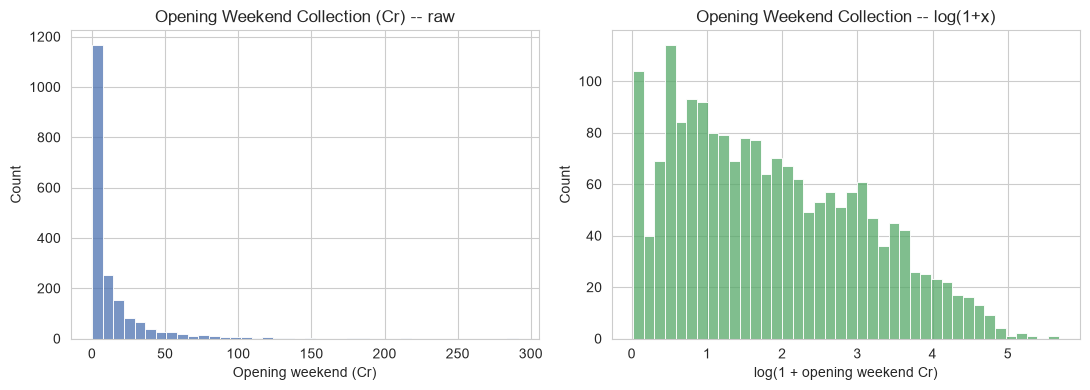

mean=13.06, median=4.34, skew=3.94 -> heavily right-skewed, log-transform recommended.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["opening_weekend_cr"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Opening Weekend Collection (Cr) -- raw")
axes[0].set_xlabel("Opening weekend (Cr)")
sns.histplot(df["log_opening_weekend"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Opening Weekend Collection -- log(1+x)")
axes[1].set_xlabel("log(1 + opening weekend Cr)")
plt.tight_layout()
plt.show()

print(f"mean={df['opening_weekend_cr'].mean():.2f}, median={df['opening_weekend_cr'].median():.2f}, "
      f"skew={df['opening_weekend_cr'].skew():.2f} -> heavily right-skewed, log-transform recommended.")

**What I'm seeing:** most films make very little and a few blockbusters stretch the scale. That's why I use the log version (right), otherwise a handful of hits dominate the models.

## 2. Pre- vs. Post-COVID Comparison

Pre-COVID = 2013-2019 (391 films), COVID = 2020-21 (170), post-COVID = 2022-2026 (1,339). I only compare pre vs post; 2020-21 is shown separately because releases were disrupted.

Two notes:
1. Only wide releases (`opening_weekend_cr >= 0.05 Cr`) are compared, since ~96% of post-COVID films qualify vs all pre-COVID ones.
2. Pre-COVID is 90% Hindi (350 of 391), so the raw gap partly reflects language mix. The regressions control for language.

Wide-release comparison basis: 1843/1900 films (pre_covid 391/391, post_covid 1282/1339)


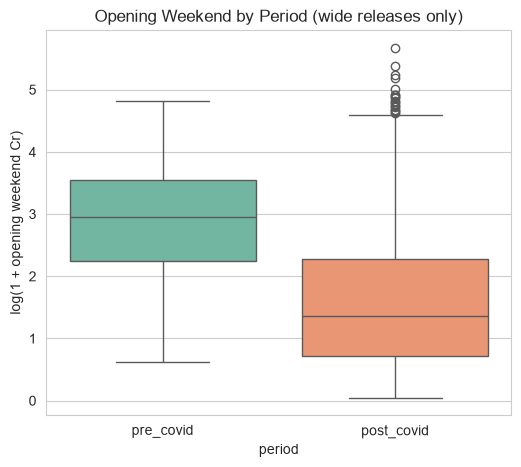


Median opening weekend (Cr), wide releases only:
period
during_covid     4.455
post_covid       2.915
pre_covid       18.150
Name: opening_weekend_cr, dtype: float64

For reference, full (unfiltered) sample medians:
period
during_covid     4.455
post_covid       2.650
pre_covid       18.150
Name: opening_weekend_cr, dtype: float64


In [3]:
wide_df = df[df["wide_release_flag"]]
n_pre = (df["period"] == "pre_covid").sum()
n_post = (df["period"] == "post_covid").sum()
n_pre_wide = (wide_df["period"] == "pre_covid").sum()
n_post_wide = (wide_df["period"] == "post_covid").sum()
print(f"Wide-release comparison basis: {len(wide_df)}/{len(df)} films "
      f"(pre_covid {n_pre_wide}/{n_pre}, post_covid {n_post_wide}/{n_post})")

plt.figure(figsize=(6, 5))
sns.boxplot(data=wide_df, x="period", y="log_opening_weekend", order=PERIOD_ORDER, hue="period",
            palette="Set2", legend=False)
plt.title("Opening Weekend by Period (wide releases only)")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

print("\nMedian opening weekend (Cr), wide releases only:")
print(wide_df.groupby("period")["opening_weekend_cr"].median())
print("\nFor reference, full (unfiltered) sample medians:")
print(df.groupby("period")["opening_weekend_cr"].median())

**What I'm seeing:** pre-COVID films open way bigger (median ₹18.15 Cr vs ₹2.92 Cr), but part of that is just language mix. With language, genre, runtime and star power controlled (Model A), pre-COVID is still about +0.98 log-points (~2.7x), so the drop is real but smaller than it looks here.

## 3. Certification Effect

Certification is available for 73.8% of films (not random, see limitations). Wide releases only.

Certification subset (wide releases only): n=1386 (72.9% of full dataset)


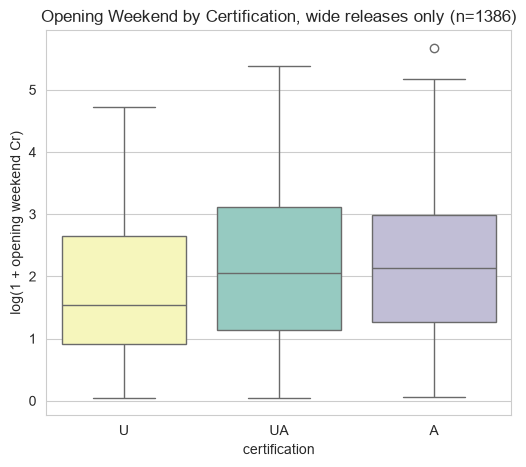

certification
U     3.65
UA    6.78
A     7.39
Name: opening_weekend_cr, dtype: float64


In [4]:
cert_df = wide_df[wide_df["has_certification"]]
print(f"Certification subset (wide releases only): n={len(cert_df)} ({len(cert_df)/len(df)*100:.1f}% of full dataset)")

plt.figure(figsize=(6, 5))
sns.boxplot(data=cert_df, x="certification", y="log_opening_weekend", order=CERT_ORDER, hue="certification",
            palette="Set3", legend=False)
plt.title(f"Opening Weekend by Certification, wide releases only (n={len(cert_df)})")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

print(cert_df.groupby("certification")["opening_weekend_cr"].median().reindex(CERT_ORDER))

**What I'm seeing:** A and UA open bigger than U (medians ₹7.39 Cr and ₹6.78 Cr vs ₹3.65 Cr), but this mixes both periods. Whether the ordering holds before and after COVID is the next chart.

## 4. Certification × Period Interaction

The main question: has certification's effect shifted pre vs post-COVID? Pre-COVID A has only 38 films. 2020-21 is shown but left out of the test.

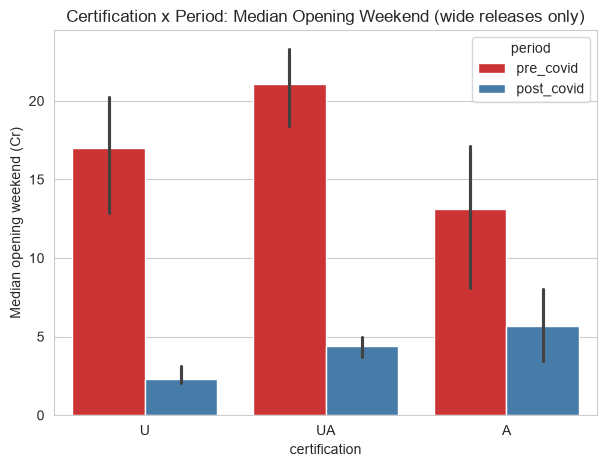

Median opening weekend (Cr):
period         during_covid  post_covid  pre_covid
certification                                     
U                     4.100        2.33     17.010
UA                    6.515        4.40     21.085
A                     4.300        5.65     13.150

Cell sizes (n):
period         during_covid  post_covid  pre_covid
certification                                     
U                        34         155         52
UA                       80         685        246
A                        11          85         38


In [5]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=cert_df, x="certification", y="opening_weekend_cr", hue="period",
    order=CERT_ORDER, hue_order=PERIOD_ORDER, estimator=np.median, errorbar=("ci", 95),
    palette="Set1",
)
plt.title("Certification x Period: Median Opening Weekend (wide releases only)")
plt.ylabel("Median opening weekend (Cr)")
plt.show()

pivot_median = cert_df.pivot_table(
    values="opening_weekend_cr", index="certification", columns="period",
    aggfunc="median", observed=True,
).reindex(CERT_ORDER)
pivot_n = cert_df.pivot_table(
    values="opening_weekend_cr", index="certification", columns="period",
    aggfunc="count", observed=True,
).reindex(CERT_ORDER)
print("Median opening weekend (Cr):")
print(pivot_median)
print("\nCell sizes (n):")
print(pivot_n)

**What I'm seeing:** the main result. Before COVID, A films opened the smallest (median ₹13.15 Cr vs ₹17.01 Cr for U, ₹21.09 Cr for UA). After COVID, A opens the biggest (₹5.65 Cr vs ₹4.40 Cr UA, ₹2.33 Cr U). Everything fell but U fell the most. Model B tests this (p=0.004).

## 5. Language Effect

Full dataset, since this isn't a period comparison.

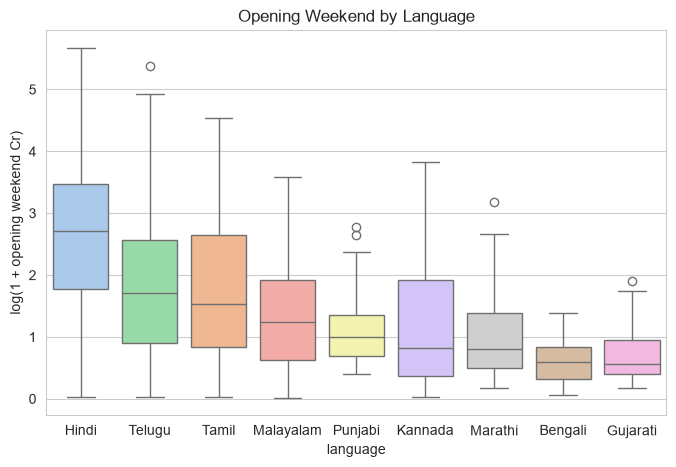

In [6]:
order = df.groupby("language")["opening_weekend_cr"].median().sort_values(ascending=False).index
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="language", y="log_opening_weekend", order=order, hue="language",
            palette="pastel", legend=False)
plt.title("Opening Weekend by Language")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

**What I'm seeing:** Hindi is on top and everything else is below it. Punjabi, Gujarati, Marathi and Bengali are the smallest and only exist from 2022. Language stays in every model as a control.

## 6. Genre Effect (top 8 by frequency)

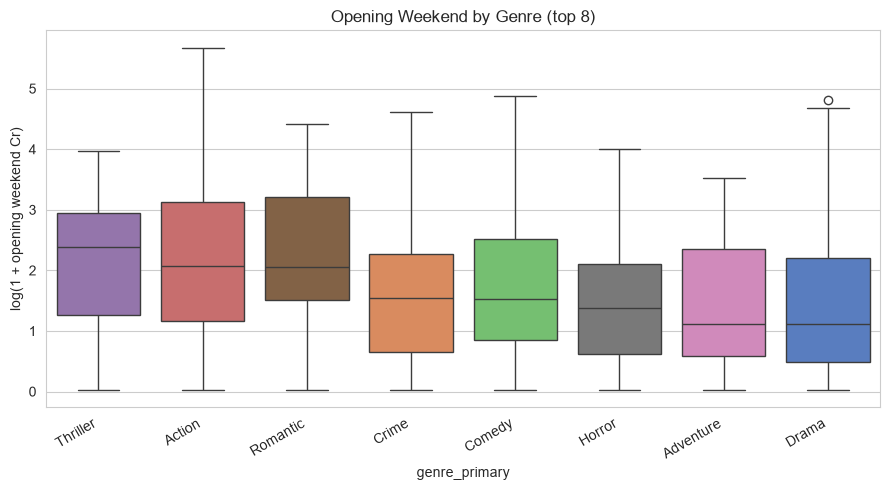

In [7]:
top_genres = df["genre_primary"].value_counts().head(8).index
genre_df = df[df["genre_primary"].isin(top_genres)]
order = genre_df.groupby("genre_primary")["opening_weekend_cr"].median().sort_values(ascending=False).index

plt.figure(figsize=(9, 5))
sns.boxplot(data=genre_df, x="genre_primary", y="log_opening_weekend", order=order, hue="genre_primary",
            palette="muted", legend=False)
plt.title("Opening Weekend by Genre (top 8)")
plt.ylabel("log(1 + opening weekend Cr)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**What I'm seeing:** on raw medians Thriller (₹9.9 Cr, only 41 films), Action (₹6.9 Cr) and Romantic (₹6.8 Cr) lead, Drama (₹2.1 Cr) is lowest. Thriller is misleading, a few big Hindi thrillers pull it up, and in Model A it ends up below Action. Trust the controlled result.

## 7. Festival Release Effect

176 of 1,900 films release in a festival window (Pongal/Sankranti, Holi, Eid, Independence Day, Diwali, Christmas).

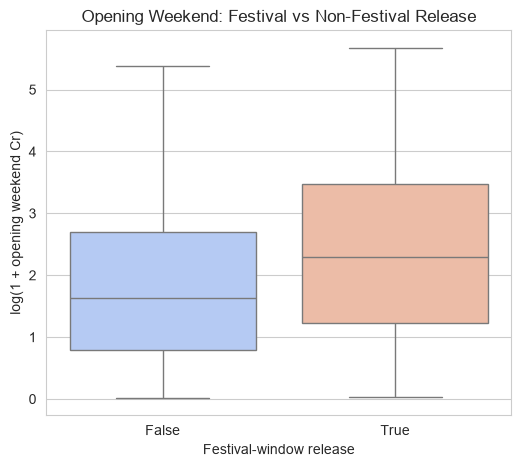

festival_release
False    4.125
True     8.975
Name: opening_weekend_cr, dtype: float64

n festival releases: 176 / 1900


In [8]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="festival_release", y="log_opening_weekend", hue="festival_release",
            palette="coolwarm", legend=False)
plt.title("Opening Weekend: Festival vs Non-Festival Release")
plt.xlabel("Festival-window release")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

print(df.groupby("festival_release")["opening_weekend_cr"].median())
print(f"\nn festival releases: {df['festival_release'].sum()} / {len(df)}")

**What I'm seeing:** festival releases open bigger (median ₹8.98 Cr vs ₹4.13 Cr) and it holds in the regression (+0.23, p=0.002).

## 8. Star Power Effect

Flag = 1 if a cast member appears in 2+ other films in this dataset. It's a same-dataset proxy, not an external star ranking.

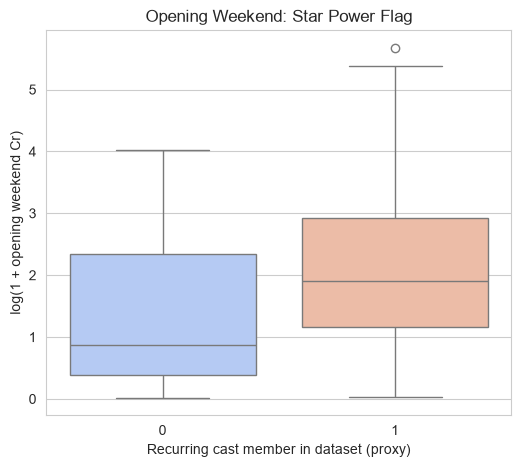

star_power_flag
0    1.39
1    5.72
Name: opening_weekend_cr, dtype: float64


In [9]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="star_power_flag", y="log_opening_weekend", hue="star_power_flag",
            palette="coolwarm", legend=False)
plt.title("Opening Weekend: Star Power Flag")
plt.xlabel("Recurring cast member in dataset (proxy)")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

print(df.groupby("star_power_flag")["opening_weekend_cr"].median())

**What I'm seeing:** films with a recurring cast member open much bigger (median ₹5.72 Cr vs ₹1.39 Cr, coefficient +0.70). But the flag now marks 69% of films so it separates less, which is why I added the time-aware version in Section 17.

## 9. Runtime vs. Opening Weekend

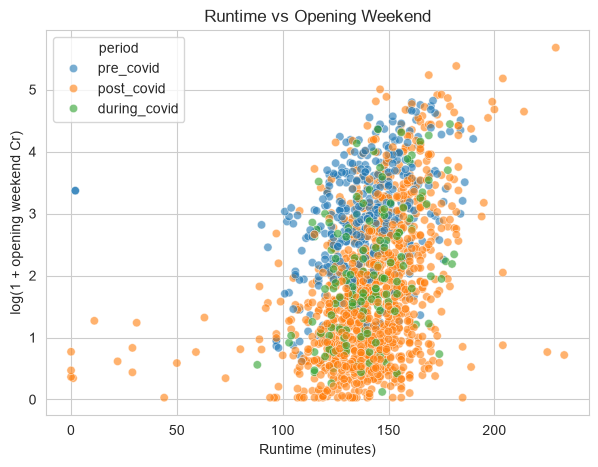

Runtime vs opening weekend correlation: 0.349


In [10]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="runtime_minutes", y="log_opening_weekend", hue="period", alpha=0.6)
plt.title("Runtime vs Opening Weekend")
plt.xlabel("Runtime (minutes)")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

corr = df[["runtime_minutes", "opening_weekend_cr"]].corr().iloc[0, 1]
print(f"Runtime vs opening weekend correlation: {corr:.3f}")

**What I'm seeing:** longer films open a bit bigger. Weak on its own but significant in the regression.

## 10. Correlation Matrix (numeric features)

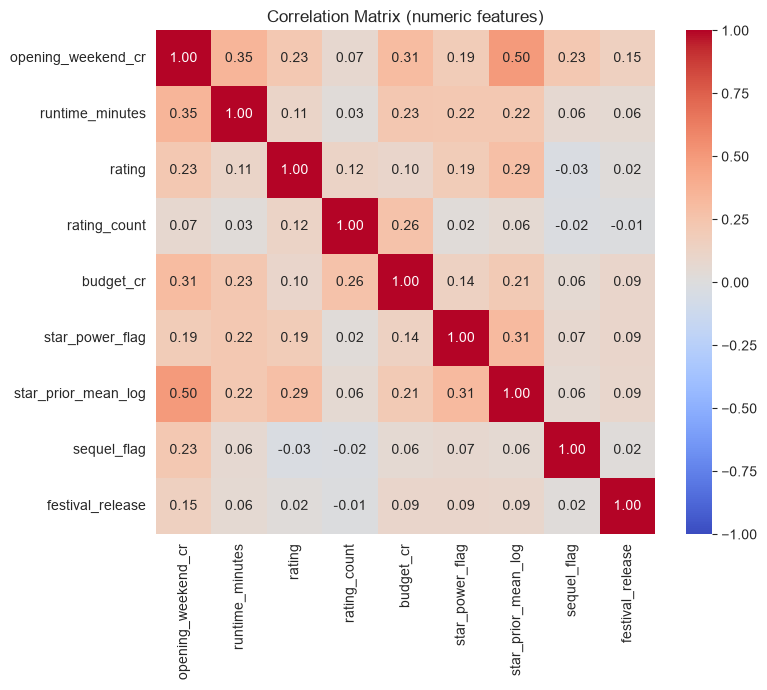

In [11]:
numeric_cols = ["opening_weekend_cr", "runtime_minutes", "rating", "rating_count", "budget_cr",
                "star_power_flag", "star_prior_mean_log", "sequel_flag", "festival_release"]
corr_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(8, 7))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix (numeric features)")
plt.tight_layout()
plt.show()

**What I'm seeing:** just a sanity check. Nothing is highly correlated with anything else.

## 11. Opening Weekend Trend, Year by Year

Checking whether the pre/post split is a clean break.

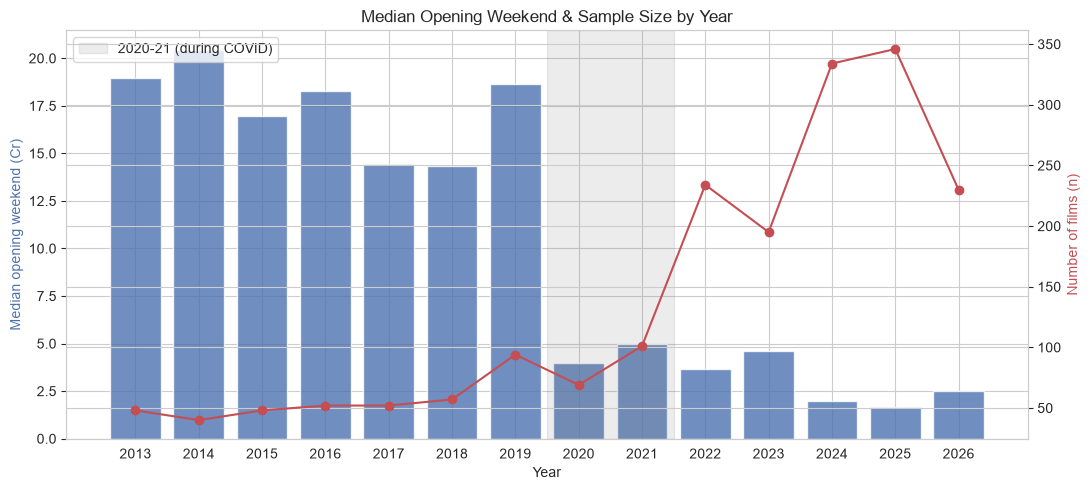

      median  count
year               
2013  18.985     48
2014  20.440     40
2015  16.990     48
2016  18.300     52
2017  14.430     52
2018  14.330     57
2019  18.665     94
2020   4.000     69
2021   5.000    101
2022   3.650    234
2023   4.600    195
2024   1.975    334
2025   1.675    346
2026   2.500    230


In [12]:
yearly = df.groupby("year")["opening_weekend_cr"].agg(["median", "count"])
years = list(yearly.index)
covid_start = years.index(min(y for y in years if y >= 2020)) - 0.5
covid_end = years.index(min(y for y in years if y >= 2022)) - 0.5

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar([str(y) for y in years], yearly["median"], color="#4C72B0", alpha=0.8)
ax1.set_ylabel("Median opening weekend (Cr)", color="#4C72B0")
ax1.set_xlabel("Year")
ax2 = ax1.twinx()
ax2.plot([str(y) for y in years], yearly["count"], color="#C44E52", marker="o")
ax2.set_ylabel("Number of films (n)", color="#C44E52")
ax1.axvspan(covid_start, covid_end, color="gray", alpha=0.15, label="2020-21 (during COVID)")
ax1.legend(loc="upper left")
plt.title("Median Opening Weekend & Sample Size by Year")
plt.tight_layout()
plt.show()

print(yearly)

**What I'm seeing:** the median is around ₹14-20 Cr through 2013-2019, drops to ₹4-5 Cr in 2020-21 and stays low after (₹1.7-4.6 Cr). It's a real step change, but post-COVID also has far more small films and languages, so I trust the regression more than this chart.

## 12. Budget vs. Opening Weekend

Sacnilk uses ₹1 Cr as a placeholder for unknown budgets, so I excluded those. Real budget coverage is 45.9% (873 of 1,900 films).

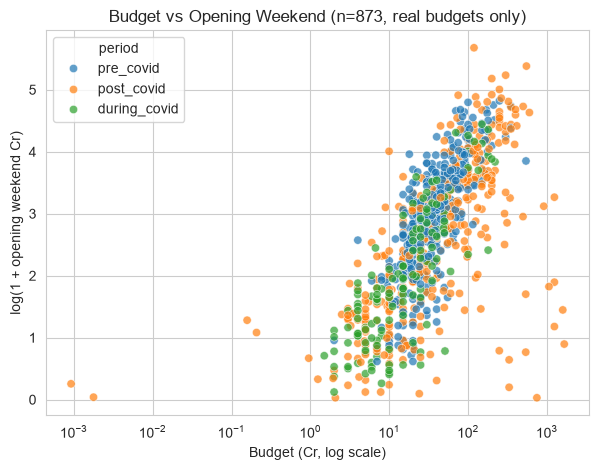

Correlation, raw Cr scale: 0.310
Correlation, log scale:    0.698
Placeholder budgets (<=1 Cr) already excluded; coverage 873/1900 (45.9%)


In [13]:
budget_df = df.dropna(subset=["budget_cr"])

plt.figure(figsize=(7, 5))
sns.scatterplot(data=budget_df, x="budget_cr", y="log_opening_weekend", hue="period", alpha=0.7)
plt.xscale("log")
plt.title(f"Budget vs Opening Weekend (n={len(budget_df)}, real budgets only)")
plt.xlabel("Budget (Cr, log scale)")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

raw_corr = budget_df[["budget_cr", "opening_weekend_cr"]].corr().iloc[0, 1]
log_corr = np.log1p(budget_df[["budget_cr", "opening_weekend_cr"]]).corr().iloc[0, 1]
print(f"Correlation, raw Cr scale: {raw_corr:.3f}")
print(f"Correlation, log scale:    {log_corr:.3f}")
print(f"Placeholder budgets (<=1 Cr) already excluded; coverage {len(budget_df)}/{len(df)} ({len(budget_df)/len(df)*100:.1f}%)")

**What I'm seeing:** budget and opening weekend are related: 0.31 correlation raw, 0.70 on the log scale (fairer, since a few blockbusters dominate the raw one). I left budget out of the regression since it covers under half the films and overlaps with star power.

## 13. TMDb Rating vs. Opening Weekend

Rating comes after release so it can't be a predictor. Just a gut-check.

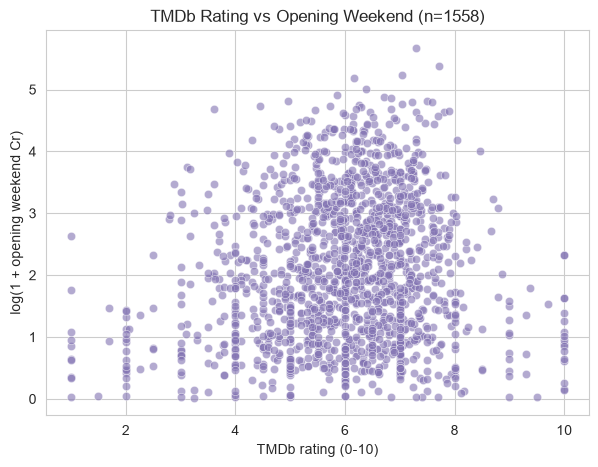

Correlation: 0.088


In [14]:
rating_df = df[(df["rating"].notna()) & (df["rating"] > 0)]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=rating_df, x="rating", y="log_opening_weekend", alpha=0.6, color="#8172B2")
plt.title(f"TMDb Rating vs Opening Weekend (n={len(rating_df)})")
plt.xlabel("TMDb rating (0-10)")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

print(f"Correlation: {rating_df[['rating','opening_weekend_cr']].corr().iloc[0,1]:.3f}")

**What I'm seeing:** almost no relationship (0.09). Makes sense, opening weekend is driven by hype before ratings exist. Films with 0 rating and 0 votes are excluded.

## 14. Certification Coverage by Language

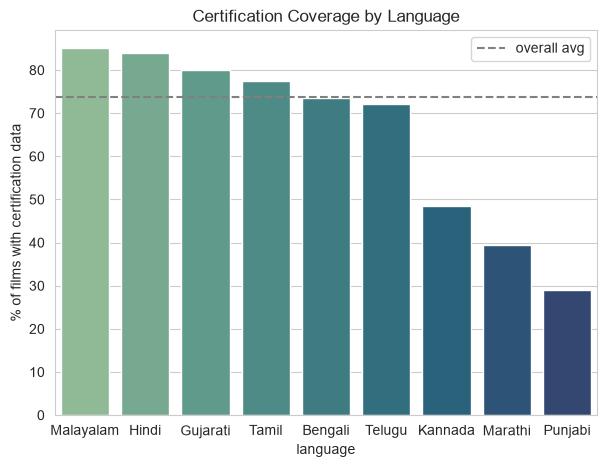

language
Malayalam    0.850220
Hindi        0.840376
Gujarati     0.800000
Tamil        0.775510
Bengali      0.734694
Telugu       0.720930
Kannada      0.485294
Marathi      0.394366
Punjabi      0.288889
Name: has_certification, dtype: float64


In [15]:
cert_coverage = df.groupby("language")["has_certification"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=cert_coverage.index, y=cert_coverage.values * 100, hue=cert_coverage.index,
            palette="crest", legend=False)
plt.title("Certification Coverage by Language")
plt.ylabel("% of films with certification data")
plt.axhline(y=df["has_certification"].mean()*100, color="gray", linestyle="--", label="overall avg")
plt.legend()
plt.show()

print(cert_coverage)

**What I'm seeing:** good for Malayalam (85%), Hindi (84%), Gujarati (80%), Tamil (78%), Bengali (73%), Telugu (72%). Poor for Kannada (49%), Marathi (39%), Punjabi (29%), so I wouldn't read language-specific certification results for those.

## 15. Lead Cast Popularity vs. Opening Weekend

`lead_cast_popularity` is the max TMDb popularity among the top-5 billed cast.

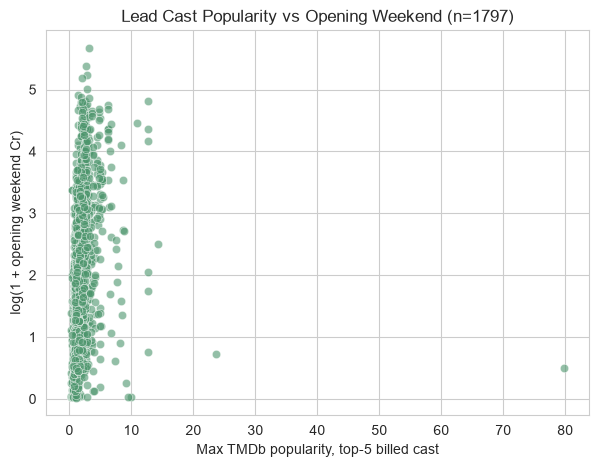

Correlation: 0.190
For comparison, same-dataset star_power_flag split:
star_power_flag
0    1.39
1    5.72
Name: opening_weekend_cr, dtype: float64


In [16]:
pop_df = df.dropna(subset=["lead_cast_popularity"])

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pop_df, x="lead_cast_popularity", y="log_opening_weekend", alpha=0.6, color="#4C956C")
plt.title(f"Lead Cast Popularity vs Opening Weekend (n={len(pop_df)})")
plt.xlabel("Max TMDb popularity, top-5 billed cast")
plt.ylabel("log(1 + opening weekend Cr)")
plt.show()

print(f"Correlation: {pop_df[['lead_cast_popularity','opening_weekend_cr']].corr().iloc[0,1]:.3f}")
print(f"For comparison, same-dataset star_power_flag split:")
print(df.groupby("star_power_flag")["opening_weekend_cr"].median())

**What I'm seeing:** weak (0.19). TMDb popularity is measured today, not at release, so it's not a fair measure. Left out of the models.

## 16. Dataset Coverage: Films by Language and Year

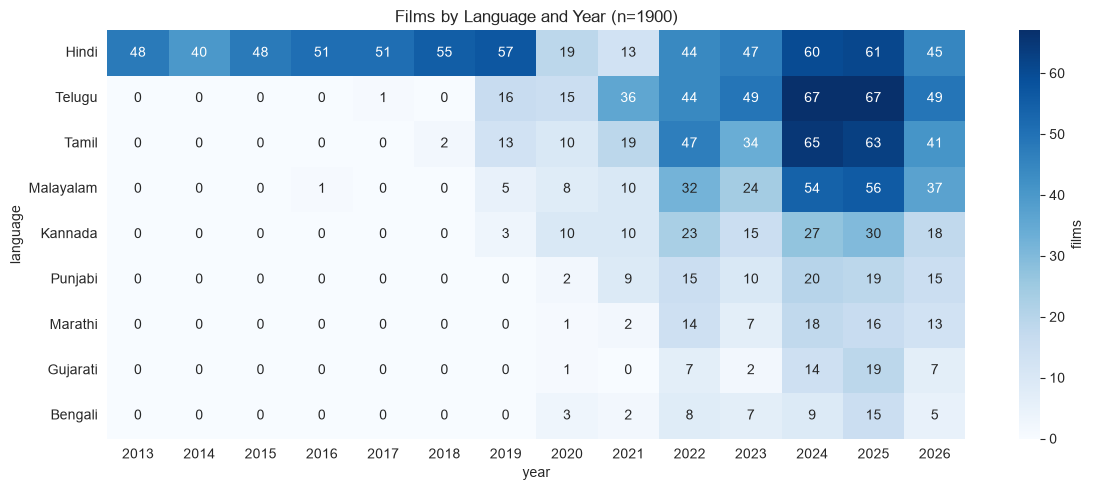

period
during_covid     170
post_covid      1339
pre_covid        391
dtype: int64


In [17]:
comp = df.groupby(["language", "year"]).size().unstack(fill_value=0)
comp = comp.loc[comp.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12, 5))
sns.heatmap(comp, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "films"})
plt.title(f"Films by Language and Year (n={len(df)})")
plt.tight_layout()
plt.show()

print(df.groupby("period").size())

**What I'm seeing:** only Hindi has a real pre-COVID history (350 films). Tamil, Telugu, Malayalam and Kannada have just 3-17 films each before 2020 because Sacnilk doesn't track them, and the other four languages start in 2022. So the pre/post comparison rests mostly on Hindi.

## 17. Time-Aware Star Power vs. Opening Weekend

`star_prior_mean_log` uses only a cast member's earlier films in the dataset (top-3 billed, best of the three), so it can't see the future. Films with no earlier film are shown separately.

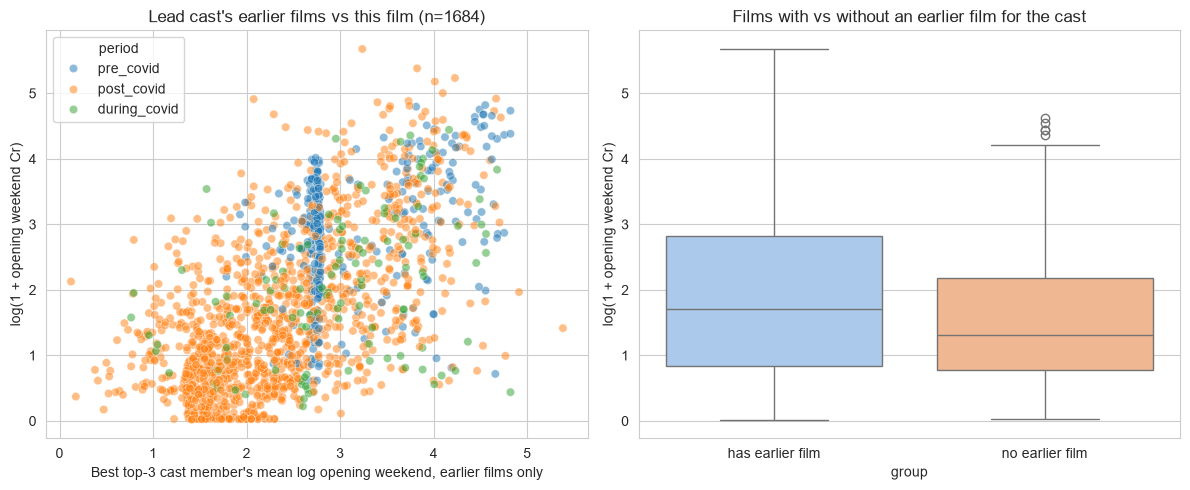

Correlation (earlier-films measure vs opening weekend, log scale): 0.615
Films with no earlier film for any top-3 cast: 216 (11.4%)


In [18]:
prior_df = df.dropna(subset=["star_prior_mean_log"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=prior_df, x="star_prior_mean_log", y="log_opening_weekend", hue="period", alpha=0.5, ax=axes[0])
axes[0].set_title(f"Lead cast's earlier films vs this film (n={len(prior_df)})")
axes[0].set_xlabel("Best top-3 cast member's mean log opening weekend, earlier films only")
axes[0].set_ylabel("log(1 + opening weekend Cr)")
no_prior = df[df["star_prior_mean_log"].isna()]
sns.boxplot(data=pd.concat([prior_df.assign(group="has earlier film"), no_prior.assign(group="no earlier film")]),
            x="group", y="log_opening_weekend", hue="group", palette="pastel", legend=False, ax=axes[1])
axes[1].set_title("Films with vs without an earlier film for the cast")
axes[1].set_ylabel("log(1 + opening weekend Cr)")
plt.tight_layout()
plt.show()

print(f"Correlation (earlier-films measure vs opening weekend, log scale): "
      f"{prior_df[['star_prior_mean_log','log_opening_weekend']].corr().iloc[0,1]:.3f}")
print(f"Films with no earlier film for any top-3 cast: {len(no_prior)} ({len(no_prior)/len(df)*100:.1f}%)")

**What I'm seeing:** clear upward relationship (0.62), much stronger than the flag or TMDb popularity. 216 films (11%) have no earlier film for any top-3 cast and open smaller. Since it only uses earlier films, it works before release.

## Data Completeness Summary

In [19]:
for col in ["certification", "runtime_minutes", "rating", "budget_cr", "lead_cast_popularity"]:
    n = df[col].notna().sum()
    print(f"{col}: {n}/{len(df)} ({n/len(df)*100:.1f}%)")
print("\n(budget_cr excludes Sacnilk's placeholder budgets of 1 Cr or less -- see Section 12.)")

certification: 1402/1900 (73.8%)
runtime_minutes: 1586/1900 (83.5%)
rating: 1811/1900 (95.3%)
budget_cr: 873/1900 (45.9%)
lead_cast_popularity: 1797/1900 (94.6%)

(budget_cr excludes Sacnilk's placeholder budgets of 1 Cr or less -- see Section 12.)


---
# Phase 8: Explanatory Regression (Objectives 1 & 3)

- **Model A**: genre, language, runtime, timing, star power and sequel on all films with runtime and genre (n=1,555). Certification is left out so no rows are dropped.
- **Model B**: certification × period on wide-release films with certification (n=1,261).

Standard errors are clustered by film, since one pan-India film shows up once per language version. Genres with <5 films are grouped as "Other". Reference categories: Hindi and post-COVID.

In [20]:
import statsmodels.formula.api as smf

genre_counts = df["genre_primary"].value_counts()
rare_genres = genre_counts[genre_counts < 5].index
df["genre_grouped"] = df["genre_primary"].apply(lambda g: "Other" if g in rare_genres else g)
print("Genre categories used in modeling:")
print(df["genre_grouped"].value_counts())

Genre categories used in modeling:
genre_grouped
Action          577
Comedy          498
Drama           436
Crime            91
Adventure        44
Thriller         41
Romantic         31
Other            27
Horror           26
Mystery          25
Biography        23
Biopic           16
Black Comedy      8
Historical        8
Fantasy           6
Suspense          5
Sci-Fi            5
Name: count, dtype: int64


## Model A: Genre, Language, Runtime, Timing, Star Power

In [21]:
model_a_df = df.dropna(subset=["runtime_minutes", "genre_grouped"]).copy()
model_a = smf.ols(
    "log_opening_weekend ~ C(genre_grouped) + C(language, Treatment('Hindi')) + runtime_minutes "
    "+ star_power_flag + festival_release + sequel_flag + C(period, Treatment('post_covid'))",
    data=model_a_df,
).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(model_a_df["sacnilk_slug"])[0]})

print(f"Model A -- n={int(model_a.nobs)} (of {len(df)}; rows missing runtime or genre dropped)")
print("Standard errors clustered by film (per-language versions of one film share a slug).")
print(model_a.summary())

Model A -- n=1555 (of 1900; rows missing runtime or genre dropped)
Standard errors clustered by film (per-language versions of one film share a slug).
                             OLS Regression Results                            
Dep. Variable:     log_opening_weekend   R-squared:                       0.519
Model:                             OLS   Adj. R-squared:                  0.509
Method:                  Least Squares   F-statistic:                     63.48
Date:                 Mon, 21 Sep 2026   Prob (F-statistic):          1.49e-244
Time:                         23:11:16   Log-Likelihood:                -1921.9
No. Observations:                 1555   AIC:                             3906.
Df Residuals:                     1524   BIC:                             4072.
Df Model:                           30                                         
Covariance Type:               cluster                                         
                                                 

## Model B: Certification × Period Interaction

Language is controlled; genre and runtime are left out to keep the sample size for the interaction.

In [22]:
cert_model_df = df[(df["wide_release_flag"]) & (df["has_certification"])
                   & (df["period"].isin(["pre_covid", "post_covid"]))].copy()

model_b = smf.ols(
    "log_opening_weekend ~ C(certification, Treatment(reference='U')) * C(period, Treatment('post_covid')) "
    "+ C(language, Treatment('Hindi'))",
    data=cert_model_df,
).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(cert_model_df["sacnilk_slug"])[0]})

print(f"Model B -- n={int(model_b.nobs)} (pre/post-COVID only; 2020-21 films excluded from this comparison)")
print("Standard errors clustered by film.")
print(model_b.summary())

Model B -- n=1261 (pre/post-COVID only; 2020-21 films excluded from this comparison)
Standard errors clustered by film.
                             OLS Regression Results                            
Dep. Variable:     log_opening_weekend   R-squared:                       0.310
Model:                             OLS   Adj. R-squared:                  0.302
Method:                  Least Squares   F-statistic:                     97.64
Date:                 Mon, 21 Sep 2026   Prob (F-statistic):          5.35e-180
Time:                         23:11:16   Log-Likelihood:                -1810.0
No. Observations:                 1261   AIC:                             3648.
Df Residuals:                     1247   BIC:                             3720.
Df Model:                           13                                         
Covariance Type:               cluster                                         
                                                                                

## Robustness Checks

1. **Time-aware star power**: the original flag can see films released after the one being explained, so I redo it using only earlier films.
2. **Hindi only**: pre-COVID is mostly Hindi, so if the certification result were just language mix it should vanish here.

In [23]:
groups = lambda d: pd.factorize(d["sacnilk_slug"])[0]

# 1. time-aware star power (films with no earlier film for any top-3 cast get 0 + an indicator)
a2 = model_a_df.copy()
a2["has_prior_star_film"] = a2["star_prior_mean_log"].notna().astype(int)
a2["star_prior_mean_log_f"] = a2["star_prior_mean_log"].fillna(0)
model_a2 = smf.ols(
    "log_opening_weekend ~ C(genre_grouped) + C(language, Treatment('Hindi')) + runtime_minutes "
    "+ star_prior_mean_log_f + has_prior_star_film + festival_release + sequel_flag "
    "+ C(period, Treatment('post_covid'))",
    data=a2,
).fit(cov_type="cluster", cov_kwds={"groups": groups(a2)})
tbl = model_a2.summary2().tables[1]
keep = [i for i in tbl.index if i.startswith(("star_prior", "has_prior", "runtime", "festival", "sequel", "C(period"))]
print(f"Robustness 1 -- time-aware star power (n={int(model_a2.nobs)}, R2={model_a2.rsquared:.3f})")
print(tbl.loc[keep, ["Coef.", "Std.Err.", "P>|z|"]].round(4))

# 2. certification x period, Hindi only
hindi = cert_model_df[cert_model_df["language"] == "Hindi"]
model_b_hindi = smf.ols(
    "log_opening_weekend ~ C(certification, Treatment(reference='U')) * C(period, Treatment('post_covid'))",
    data=hindi,
).fit(cov_type="cluster", cov_kwds={"groups": groups(hindi)})
print(f"\nRobustness 2 -- certification x period, Hindi only (n={int(model_b_hindi.nobs)})")
print(model_b_hindi.summary2().tables[1][["Coef.", "Std.Err.", "P>|z|"]].round(4))
print("\nCell sizes, Hindi only:")
print(hindi.groupby(["certification", "period"]).size().unstack(fill_value=0))

Robustness 1 -- time-aware star power (n=1555, R2=0.540)
                                                     Coef.  Std.Err.   P>|z|
festival_release[T.True]                            0.2364    0.0715  0.0009
C(period, Treatment('post_covid'))[T.during_covid]  0.1237    0.0789  0.1167
C(period, Treatment('post_covid'))[T.pre_covid]     0.6878    0.0635  0.0000
runtime_minutes                                     0.0151    0.0015  0.0000
star_prior_mean_log_f                               0.4491    0.0325  0.0000
has_prior_star_film                                -0.9271    0.1035  0.0000
sequel_flag                                         0.6186    0.0760  0.0000

Robustness 2 -- certification x period, Hindi only (n=507)
                                                     Coef.  Std.Err.   P>|z|
Intercept                                           1.6526    0.2617  0.0000
C(certification, Treatment(reference='U'))[T.A]     1.0393    0.3455  0.0026
C(certification, Treatment(reference

**Results:**

1. Time-aware star power holds up (+0.45, p<0.001) and fits better (R² 0.540 vs 0.519). Sequel, festival and pre-COVID stay significant. (The negative "has earlier film" coefficient comes from filling missing values with 0.)
2. The certification result survives inside Hindi (n=507): A×pre-COVID -1.40 (p<0.001), UA×pre-COVID -0.85 (p=0.007). So it isn't a language artifact. U lost the most after COVID, A the least.

## Interpretation

**Model A (n=1,555, R²=0.519):**

- Star power (+0.70), sequel (+0.59) and runtime (+0.017/min) are the clearest drivers (p<0.001). Sequels open ~1.8x bigger.
- Pre-COVID films open +0.98 log-points higher with everything controlled. 2020-21 is in between (+0.17).
- All eight non-Hindi languages open below Hindi, from about -0.4 (Tamil/Telugu) to about -1.0 (Marathi/Bengali).
- Relative to Action, Drama, Mystery, Biography, Comedy, Crime and Thriller are all lower.
- Festival release: +0.23 (p=0.002).

**Model B (n=1,261):**

| Term | Coefficient | p |
|---|---|---|
| UA vs U (post-COVID) | +0.25 | 0.005 |
| A vs U (post-COVID) | +0.29 | 0.066 |
| Pre-COVID vs post-COVID (for U) | +0.78 | <0.001 |
| **A × pre-COVID** | **-0.67** | **0.004** |
| UA × pre-COVID | -0.12 | 0.451 |

Post-COVID, UA and A both open above U. Pre-COVID, A opened below U (+0.29 - 0.67 = -0.38).

**Objective 3:** yes, the effect has shifted. A went from weakest to strongest and U fell hardest. Limits: pre-COVID A is only 38 films, pre-COVID is 90% Hindi, and the effect weakens when genre and runtime are added, so it's an association, not proof of cause.

---
# Phase 9: Predictive Model (Objective 2)

Goal: an expected opening weekend range from pre-release information. Missing certification becomes an "Unknown" category, and missing runtime gets a missing-indicator plus median fill.

New features: sequel flag and the time-aware star measure (mean log opening of the best top-3 cast member's earlier films, plus how many earlier films they have).

The train/test split is grouped by film. Otherwise language versions of one film end up on both sides and inflate the score.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

model_df = df.copy()
model_df["certification_pred"] = model_df["certification"].fillna("Unknown")
model_df["runtime_missing"] = model_df["runtime_minutes"].isna().astype(int)
model_df["runtime_minutes_imputed"] = model_df["runtime_minutes"].fillna(model_df["runtime_minutes"].median())
model_df["has_prior_star_film"] = model_df["star_prior_mean_log"].notna().astype(int)
model_df["star_prior_mean_log_f"] = model_df["star_prior_mean_log"].fillna(0)

feature_cols = ["genre_grouped", "language", "certification_pred", "period",
                "runtime_minutes_imputed", "runtime_missing", "star_power_flag", "festival_release",
                "sequel_flag", "star_prior_mean_log_f", "has_prior_star_film", "star_prior_count"]
categorical = ["genre_grouped", "language", "certification_pred", "period"]

X = model_df[feature_cols]
y = model_df["log_opening_weekend"]

# Group-aware split: per-language versions of one film share a slug and many attributes,
# so they must land on the same side of the split or the test score is inflated.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=model_df["sacnilk_slug"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(f"Train: {len(X_train)}, Test: {len(X_test)} (split by film, not by row)")

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
], remainder="passthrough")

Train: 1520, Test: 380 (split by film, not by row)


## Baseline (Linear Regression) vs Random Forest

In [25]:
def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    pred_cr = np.expm1(pred_log)
    actual_cr = np.expm1(y_test)
    r2_log = r2_score(y_test, pred_log)
    mae_cr = mean_absolute_error(actual_cr, pred_cr)
    print(f"{name}: R^2 (log scale) = {r2_log:.3f} | MAE (Cr) = {mae_cr:.2f}")
    return pipe, pred_log

lin_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])
rf_pipe = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(
    n_estimators=300, max_depth=6, min_samples_leaf=4, random_state=42))])

lin_pipe, lin_pred = evaluate("Linear Regression", lin_pipe)
rf_pipe, rf_pred = evaluate("Random Forest", rf_pipe)

Linear Regression: R^2 (log scale) = 0.569 | MAE (Cr) = 8.40


Random Forest: R^2 (log scale) = 0.602 | MAE (Cr) = 8.07


## Feature Importance (Random Forest)

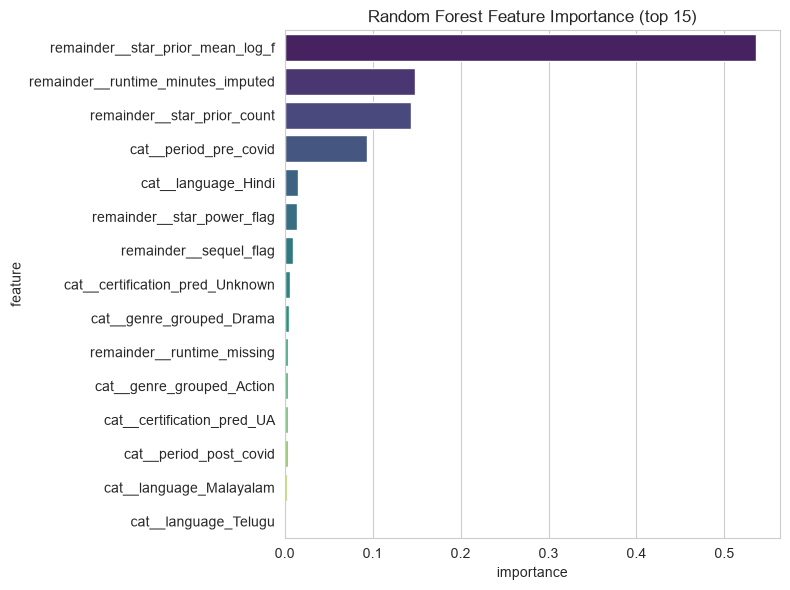

                           feature  importance
  remainder__star_prior_mean_log_f       0.536
remainder__runtime_minutes_imputed       0.149
       remainder__star_prior_count       0.144
             cat__period_pre_covid       0.094
               cat__language_Hindi       0.015
        remainder__star_power_flag       0.014
            remainder__sequel_flag       0.009
   cat__certification_pred_Unknown       0.006
          cat__genre_grouped_Drama       0.005
        remainder__runtime_missing       0.004


In [26]:
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_
imp_all = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
imp_df = imp_all.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title("Random Forest Feature Importance (top 15)")
plt.tight_layout()
plt.show()

print(imp_all.head(10).round(3).to_string(index=False))

**What I'm seeing:** the time-aware star measure dominates (0.54), then runtime (0.15), number of earlier cast films (0.14) and pre-COVID (0.09). Everything else is small. Certification barely shows up because importance scores can't capture an interaction, which is what Model B is for.

## Turning a Point Prediction into a Range

The proposal asks for a range, so I use the test-set residuals (log space) to get an empirical 80% interval and apply it to a prediction.

In [27]:
residuals_log = y_test.values - rf_pred
lower_q, upper_q = np.percentile(residuals_log, [10, 90])
print(f"80% empirical residual band (log space): [{lower_q:.3f}, {upper_q:.3f}]")

def predict_range(new_film_df):
    """new_film_df: a DataFrame with the same feature_cols as one row per film."""
    point_log = rf_pipe.predict(new_film_df)
    point_cr = np.expm1(point_log)
    low_cr = np.expm1(point_log + lower_q)
    high_cr = np.expm1(point_log + upper_q)
    return pd.DataFrame({
        "predicted_cr": point_cr, "range_low_cr": low_cr, "range_high_cr": high_cr,
    })

# Example: a hypothetical wide UA-certified Hindi action film, 140 min, not a sequel, whose lead
# has earlier films in the data at the typical (median) level, post-COVID, not a festival window.
typical_star = model_df.loc[model_df["has_prior_star_film"] == 1, "star_prior_mean_log_f"].median()
typical_count = model_df.loc[model_df["has_prior_star_film"] == 1, "star_prior_count"].median()
example = pd.DataFrame([{
    "genre_grouped": "Action", "language": "Hindi", "certification_pred": "UA",
    "period": "post_covid", "runtime_minutes_imputed": 140, "runtime_missing": 0,
    "star_power_flag": 1, "festival_release": 0, "sequel_flag": 0,
    "star_prior_mean_log_f": typical_star, "has_prior_star_film": 1, "star_prior_count": typical_count,
}])
print("\nExample prediction:")
print(predict_range(example))

80% empirical residual band (log space): [-0.926, 0.906]

Example prediction:
   predicted_cr  range_low_cr  range_high_cr
0      4.357411      1.122345      12.254998


## Interpretation

- Random Forest R²=0.602 vs Linear Regression 0.569 on a film-grouped hold-out. A random split gave 0.63 but that was inflated by leakage.
- MAE is about ₹8 Cr against a ₹4.3 Cr median. That's expected since a few blockbusters (up to ₹291 Cr) dominate the error. It ranks films better than it pins exact numbers.
- Example: UA Hindi action film, 140 min, non-sequel, typical cast, post-COVID, no festival gives ₹4.36 Cr with an 80% range of ₹1.12-12.25 Cr. Wide, but that's the honest answer: pre-release attributes narrow things down without removing the uncertainty.

---
# Phase 10: Business Recommendations

**Producers (certification):** the pre-COVID ordering has reversed and U-rated films now do worst. Cutting a film just to get a U certificate isn't automatically the safer commercial choice. That said, this doesn't mean chasing an A: the data shows how films with each certificate opened, not what happens if you re-cut one.

**Distributors (timing):** festival releases open ~26% bigger after controls. Plan screens and marketing around Pongal/Sankranti, Holi, Eid, Independence Day, Diwali and Christmas.

**Screen allocation and marketing:** cast track record is the strongest signal, better than a simple "has a star" flag. Sequels open ~1.8x bigger and each extra 10 minutes of runtime goes with ~18% higher opening.

**Multiplex chains:** the 80% range for a mid-tier film is roughly ₹1-12 Cr around ₹4.4 Cr, so keep screen allocation flexible after day one.

**Language:** every non-Hindi industry opens below Hindi even after controls (mostly market size), so benchmark per language.

---
# Data Limitations

- **Pre-COVID is 90% Hindi.** Sacnilk barely tracks other languages before 2019 and four languages start in 2022. I checked the API across all years, so it's the source and not the scraper. Hence the Hindi-only check.
- **Certification coverage is 73.8%** and uneven (Kannada 49%, Marathi 39%, Punjabi 29%). Certified films skew larger, so results describe the certified subsample.
- **Budget coverage is 45.9%** after removing the ₹1 Cr placeholder. Not used in the models.
- **Language versions of a film aren't independent**, so errors are clustered by film and the train/test split is by film.
- **Star power has three imperfect measures**: the flag (marks 69% of films), TMDb popularity (measured today) and the time-aware one (only sees films in this dataset, 11% have no earlier film).
- **Festival flag** is ±1-3 days around approximate dates; 176 films.
- **2020-21 (170 films)** is excluded from the pre/post comparison.
- **Composition:** most films come from Sacnilk's top opening weekend lists, so it leans towards notable releases (median ₹4.3 Cr). Each query is capped at 50, so I also used day-1, week-1, month-1 and collection-club rankings.
- **Runtime coverage is 83.5%**: imputed in the predictive model, dropped in Model A.